# Data Mining Final Project — Exploratory Data Analysis and Feature Engineering

This notebook explores the training dataset for the natural disaster severity prediction task and prepares a first feature engineering pipeline. The objective is to understand the structure of the data, identify useful signals, and create meaningful temporal features before training prediction models.


## 1. Imports

We import the main libraries used for data manipulation, visualization, preprocessing and baseline modeling. The first part of the notebook focuses on data exploration, while the last part creates new time-based features for drought severity prediction.


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load the Dataset

The training dataset contains daily meteorological observations for each region. The target variable, `score`, represents drought severity and is only available once per week. The other days have missing target values by design.


In [8]:
csv_path = "data/train.csv"

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")


Dataset loaded successfully.
Shape: 12319040 rows and 17 columns


## 3. First Look at the Data

This step checks the first rows, column names and data types. It helps confirm whether the dataset contains region identifiers, dates, meteorological variables and the target column.


In [9]:
display(df.head())

print("Column names:")
print(df.columns.tolist())

print("Data types:")
display(df.dtypes)

,region_id,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
0,R1,3004-12-31,0.00,101.27,3.76,5.89,-0.14,-0.11,14.87,-2.37,17.24,4.23,1.45,2.58,0.24,2.34,NaN
1,R1,3005-01-01,0.00,101.26,5.37,8.81,4.59,4.60,17.28,1.14,16.14,7.96,1.83,2.38,1.18,1.21,NaN
2,R1,3005-01-02,0.01,100.81,9.32,13.09,12.74,12.74,17.38,8.21,9.17,12.96,1.96,2.49,1.39,1.09,NaN
3,R1,3005-01-03,0.02,100.51,11.40,16.01,16.08,16.08,19.24,13.77,5.47,15.82,2.13,2.67,1.74,0.93,NaN
4,R1,3005-01-04,1.93,100.16,12.20,17.98,17.04,17.04,22.85,14.27,8.58,17.86,2.91,4.25,2.13,2.11,NaN


Column names:
['region_id', 'date', 'prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range', 'score']
Data types:


region_id         str
date              str
prec          float64
surf_pre      float64
humidity      float64
tmp           float64
dp_tmp        float64
wb_tmp        float64
tmp_max       float64
tmp_min       float64
tmp_range     float64
surf_tmp      float64
wind          float64
wind_max      float64
wind_min      float64
wind_range    float64
score         float64
dtype: object

## 4. Missing Values Analysis

Missing values are especially important in this dataset because the `score` column is expected to contain many NaN values. These NaN values should not automatically be interpreted as errors: the score is measured weekly, while weather features are measured daily.


In [10]:
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if missing_values.empty:
    print("No missing values found.")
else:
    print("Columns with missing values:")
    display(missing_values.to_frame(name="missing_count"))

    missing_percentage = (missing_values / len(df) * 100).round(2)
    display(missing_percentage.to_frame(name="missing_percentage"))


Columns with missing values:


,missing_count
score,10561104


,missing_percentage
score,85.73


### Interpretation

A high number of missing values in `score` is expected because drought severity is recorded weekly. We should therefore avoid filling these missing target values with interpolation or averages. Instead, we will later use the daily meteorological variables to create rolling features, then keep only the rows where the weekly score is available.


## 5. General Dataset Information

This cell checks duplicate rows and basic descriptive statistics. It gives an overview of the scale, range and distribution of numerical variables.


In [11]:
print("General information:")
df.info()

print("Number of duplicated rows:")
print(df.duplicated().sum())

print("Basic statistics for numerical columns:")
display(df.describe())

General information:
<class 'pandas.DataFrame'>
RangeIndex: 12319040 entries, 0 to 12319039
Data columns (total 17 columns):
 #   Column      Dtype  
---  ------      -----  
 0   region_id   str    
 1   date        str    
 2   prec        float64
 3   surf_pre    float64
 4   humidity    float64
 5   tmp         float64
 6   dp_tmp      float64
 7   wb_tmp      float64
 8   tmp_max     float64
 9   tmp_min     float64
 10  tmp_range   float64
 11  surf_tmp    float64
 12  wind        float64
 13  wind_max    float64
 14  wind_min    float64
 15  wind_range  float64
 16  score       float64
dtypes: float64(15), str(2)
memory usage: 1.6 GB
Number of duplicated rows:
0
Basic statistics for numerical columns:


,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
count,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.231904e+07,1.757936e+06
mean,2.563559e+00,9.593641e+01,7.799983e+00,1.294916e+01,6.781904e+00,6.817224e+00,1.888239e+01,7.537493e+00,1.134490e+01,1.306818e+01,3.646797e+00,5.342148e+00,1.948686e+00,3.393461e+00,8.356595e-01
std,6.215294e+00,6.024206e+00,4.728641e+00,1.096413e+01,1.026720e+01,1.019635e+01,1.156382e+01,1.063924e+01,4.053179e+00,1.123523e+01,1.879692e+00,2.656599e+00,1.371303e+00,1.987169e+00,1.261490e+00
min,0.000000e+00,6.612000e+01,1.200000e-01,-3.734000e+01,-3.770000e+01,-3.746000e+01,-3.220000e+01,-4.596000e+01,2.000000e-02,-3.719000e+01,2.500000e-01,5.400000e-01,0.000000e+00,2.000000e-01,0.000000e+00
25%,0.000000e+00,9.450000e+01,3.770000e+00,4.680000e+00,-1.180000e+00,-1.150000e+00,1.056000e+01,-5.400000e-01,8.440000e+00,4.570000e+00,2.200000e+00,3.240000e+00,9.500000e-01,1.900000e+00,0.000000e+00
50%,1.400000e-01,9.786000e+01,6.760000e+00,1.420000e+01,7.280000e+00,7.280000e+00,2.067000e+01,8.180000e+00,1.130000e+01,1.427000e+01,3.250000e+00,4.850000e+00,1.680000e+00,2.940000e+00,0.000000e+00
75%,2.020000e+00,9.989000e+01,1.132000e+01,2.205000e+01,1.545000e+01,1.544000e+01,2.808000e+01,1.626000e+01,1.419000e+01,2.230000e+01,4.710000e+00,6.930000e+00,2.630000e+00,4.420000e+00,1.000000e+00
max,2.433200e+02,1.043200e+02,2.292000e+01,4.139000e+01,2.755000e+01,2.755000e+01,5.003000e+01,3.380000e+01,3.461000e+01,4.385000e+01,2.494000e+01,3.628000e+01,1.720000e+01,2.825000e+01,5.000000e+00


## 6. Categorical Variables

The main categorical variable is expected to be `region_id`. It identifies the geographic region. Region information can be useful because some regions may naturally be more exposed to drought than others.


In [12]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in categorical_cols:
    print(f"Column: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    display(df[col].value_counts(dropna=False).head(10))


C:\Users\titou\AppData\Local\Temp\ipykernel_14620\2457789855.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


Column: region_id
Number of unique values: 2248


region_id
R1     5480
R2     5480
R3     5480
R4     5480
R6     5480
R7     5480
R8     5480
R9     5480
R11    5480
R13    5480
Name: count, dtype: int64

Column: date
Number of unique values: 2487486


date
6018-12-31    9
6019-01-01    9
6019-01-02    9
6019-01-03    9
6019-01-04    9
6019-01-05    9
6019-01-06    9
6019-01-07    9
6019-01-08    9
6019-01-09    9
Name: count, dtype: int64

## 7. Numerical Distributions

The following histograms show the distribution of each numerical variable. This helps identify skewed variables, extreme values, or variables that may require aggregation over time rather than being used only as daily values.


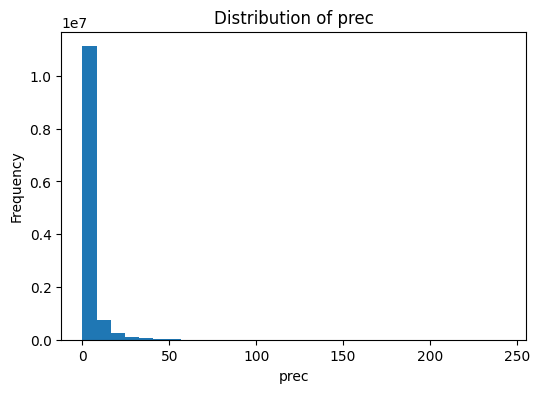

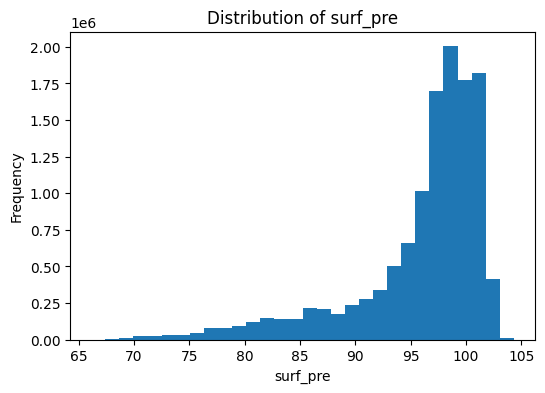

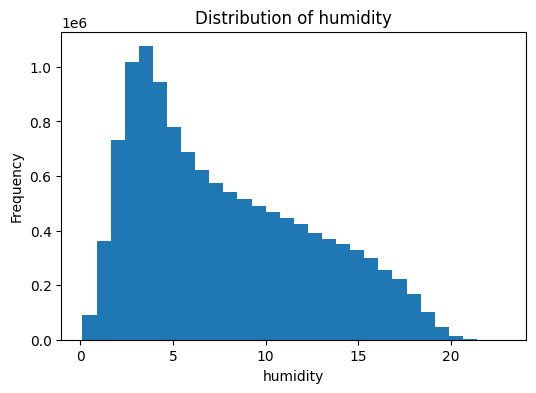

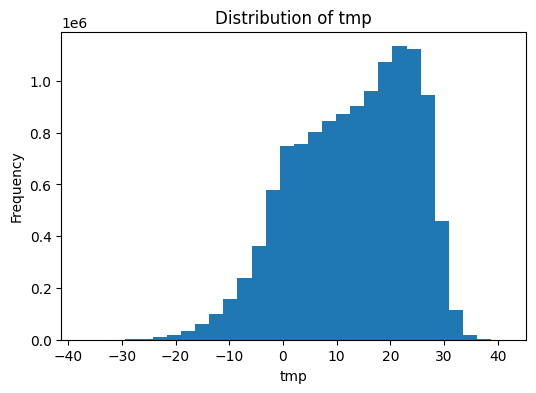

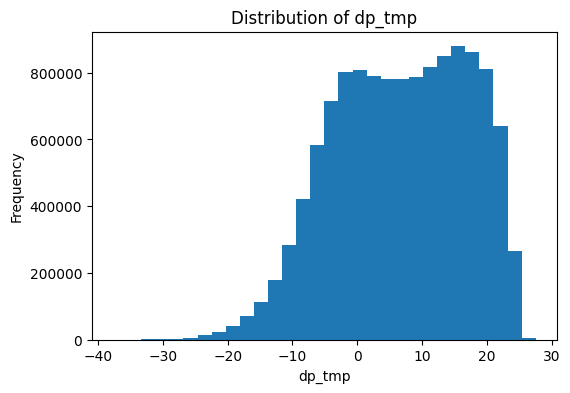

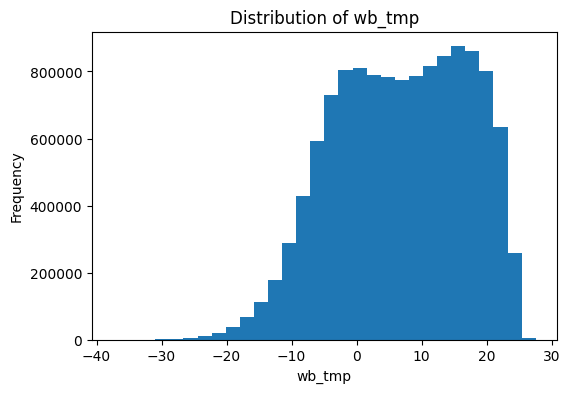

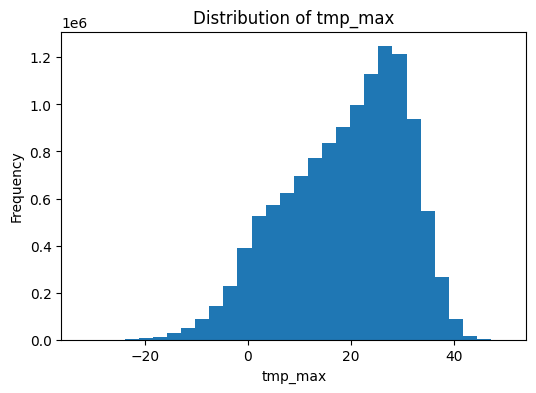

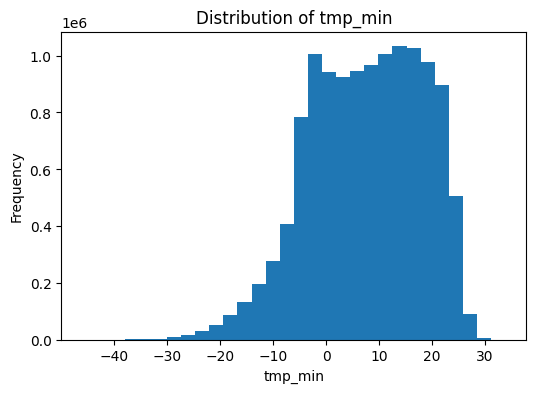

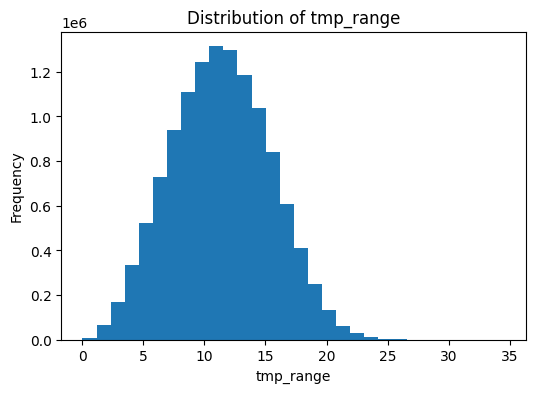

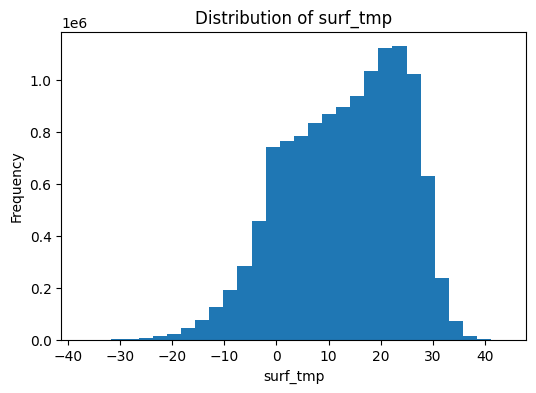

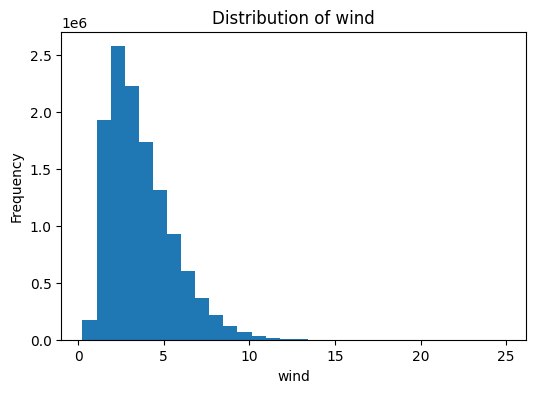

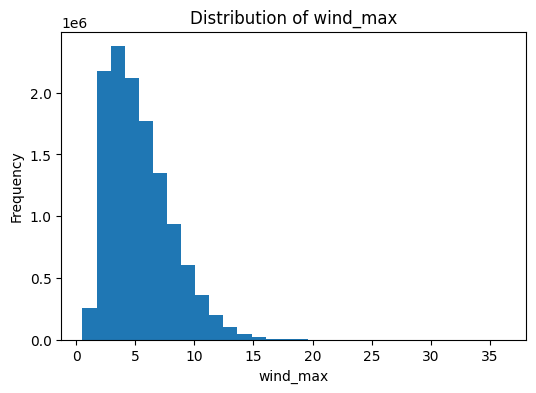

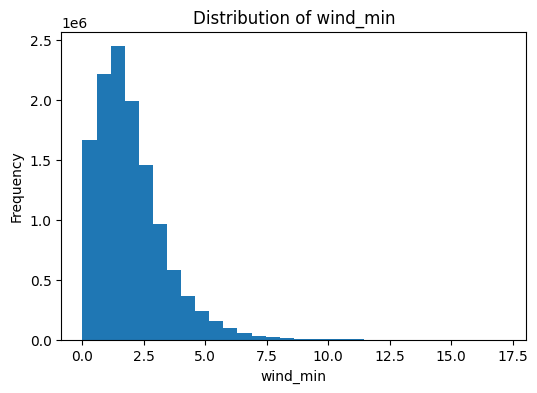

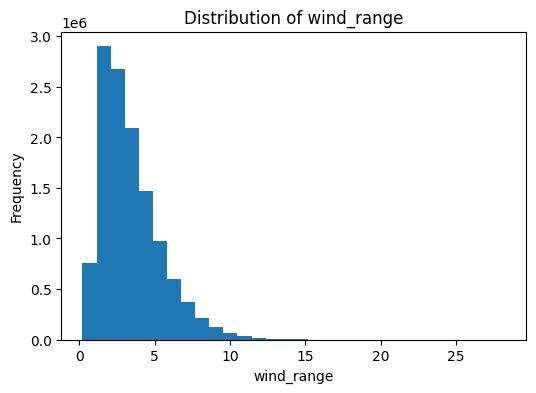

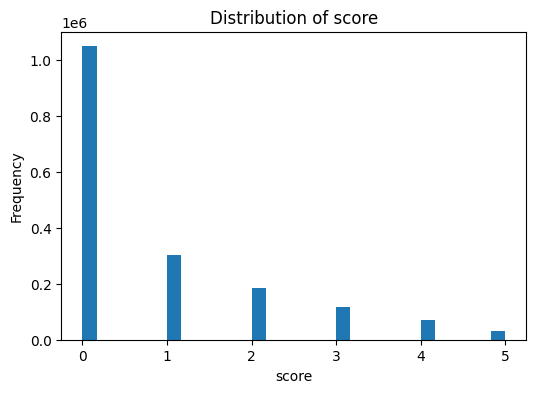

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


## 8. Correlation Matrix

The correlation matrix gives a first view of linear relationships between numerical variables. However, drought is a temporal phenomenon, so weak daily correlations do not necessarily mean that a variable is useless. Rolling accumulations and trends can be more informative than raw daily values.


,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
prec,1.000000,0.079908,0.250843,0.096370,0.234087,0.234115,0.029204,0.149530,-0.309185,0.092360,0.057836,0.062826,0.037330,0.058231,-0.060676
surf_pre,0.079908,1.000000,0.318184,0.191335,0.379792,0.380226,0.133533,0.239834,-0.248570,0.190682,-0.081349,-0.143613,0.031541,-0.213759,-0.155524
humidity,0.250843,0.318184,1.000000,0.862800,0.958749,0.960273,0.793692,0.901626,-0.102267,0.854386,-0.209090,-0.244024,-0.094926,-0.260725,-0.052438
tmp,0.096370,0.191335,0.862800,1.000000,0.905690,0.906397,0.982924,0.981525,0.227889,0.997434,-0.187212,-0.198962,-0.113882,-0.187401,0.094285
dp_tmp,0.234087,0.379792,0.958749,0.905690,1.000000,0.999914,0.843636,0.934952,-0.047253,0.896861,-0.222965,-0.256969,-0.103238,-0.272294,-0.056445
wb_tmp,0.234115,0.380226,0.960273,0.906397,0.999914,1.000000,0.844239,0.935801,-0.047762,0.897617,-0.222755,-0.256794,-0.103150,-0.272121,-0.055573
tmp_max,0.029204,0.133533,0.793692,0.982924,0.843636,0.844239,1.000000,0.936709,0.394245,0.979773,-0.190429,-0.193338,-0.127612,-0.170407,0.133983
tmp_min,0.149530,0.239834,0.901626,0.981525,0.934952,0.935801,0.936709,1.000000,0.047541,0.978634,-0.190790,-0.210815,-0.103426,-0.210461,0.060863
tmp_range,-0.309185,-0.248570,-0.102267,0.227889,-0.047253,-0.047762,0.394245,0.047541,1.000000,0.226489,-0.042490,0.001773,-0.092594,0.066265,0.221477
surf_tmp,0.092360,0.190682,0.854386,0.997434,0.896861,0.897617,0.979773,0.978634,0.226489,1.000000,-0.169975,-0.181907,-0.100201,-0.174042,0.102556


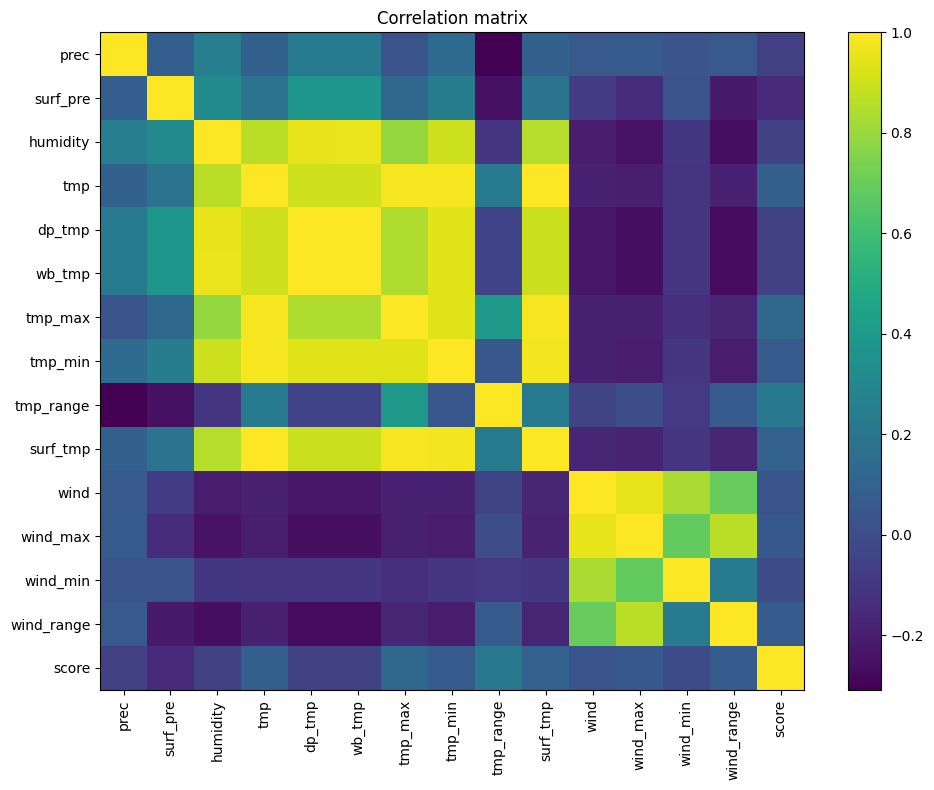

In [14]:
if len(numerical_cols) > 1:
    correlation_matrix = df[numerical_cols].corr()

    display(correlation_matrix)

    plt.figure(figsize=(10, 8))
    plt.imshow(correlation_matrix, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(numerical_cols)), numerical_cols, rotation=90)
    plt.yticks(range(len(numerical_cols)), numerical_cols)
    plt.title("Correlation matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns to compute correlations.")


## 9. Top Correlated Variable Pairs

This analysis identifies pairs of variables that contain similar information. Highly correlated variables may be redundant, but they can also reveal meaningful meteorological relationships, such as temperature-related variables moving together.


In [15]:
if len(numerical_cols) > 1:

    # Compute correlation matrix
    corr_matrix = df[numerical_cols].corr().abs()

    # Keep only upper triangle to avoid duplicates
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Convert to series and sort
    top_corr = (
        upper_triangle.stack()
        .sort_values(ascending=False)
        .head(10)
    )

    print("Top 10 most correlated variable pairs:")

    for i, ((var1, var2), corr_value) in enumerate(top_corr.items(), start=1):
        print(f"{i}. {var1} <-> {var2} : correlation = {corr_value:.4f}")

else:
    print("Not enough numerical columns to compute correlations.")


Top 10 most correlated variable pairs:
1. dp_tmp <-> wb_tmp : correlation = 0.9999
2. tmp <-> surf_tmp : correlation = 0.9974
3. tmp <-> tmp_max : correlation = 0.9829
4. tmp <-> tmp_min : correlation = 0.9815
5. tmp_max <-> surf_tmp : correlation = 0.9798
6. tmp_min <-> surf_tmp : correlation = 0.9786
7. humidity <-> wb_tmp : correlation = 0.9603
8. humidity <-> dp_tmp : correlation = 0.9587
9. wind <-> wind_max : correlation = 0.9508
10. tmp_max <-> tmp_min : correlation = 0.9367


## 10. Correlation with the Target Score

This cell ranks the variables according to their linear correlation with `score`. The objective is not to select features only from correlation values, but to identify useful directions for feature engineering. For example, if temperature range, pressure, precipitation or humidity show a relationship with drought severity, it makes sense to create rolling and trend-based features from them.


Variables most correlated with 'score':


,correlation_with_score
tmp_range,0.221477
surf_pre,-0.155524
tmp_max,0.133983
surf_tmp,0.102556
tmp,0.094285
wind_range,0.072626
tmp_min,0.060863
prec,-0.060676
dp_tmp,-0.056445
wb_tmp,-0.055573


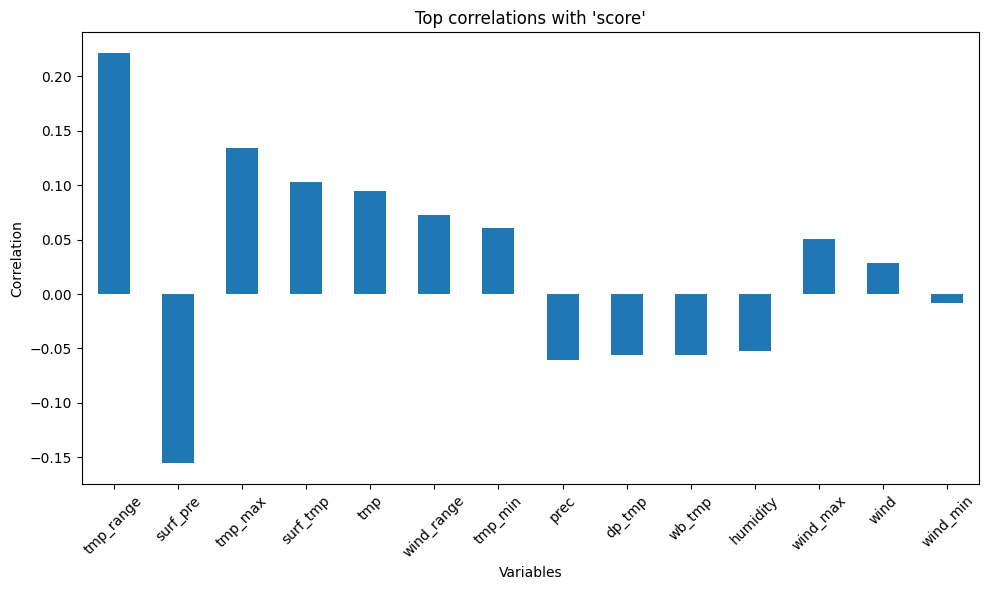

In [16]:
target_column = "score"

if target_column in df.columns:

    # Keep only numerical columns
    numerical_df = df.select_dtypes(include=["int64", "float64"])

    if target_column in numerical_df.columns:

        # Compute correlations with target
        target_corr = numerical_df.corr()[target_column]

        # Remove self-correlation
        target_corr = target_corr.drop(target_column)

        # Sort by absolute correlation value
        target_corr_sorted = target_corr.reindex(
            target_corr.abs().sort_values(ascending=False).index
        )

        print(f"Variables most correlated with '{target_column}':")

        display(target_corr_sorted.to_frame(name="correlation_with_score"))

        plt.figure(figsize=(10, 6))
        target_corr_sorted.head(15).plot(kind="bar")
        plt.title(f"Top correlations with '{target_column}'")
        plt.ylabel("Correlation")
        plt.xlabel("Variables")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    else:
        print(f"'{target_column}' is not numerical.")

else:
    print(f"Column '{target_column}' not found in dataset.")


### Interpretation for Feature Engineering

The raw daily correlations with `score` are expected to be limited because drought severity is not determined by a single daily observation. Drought is usually linked to persistent conditions: low precipitation over several weeks, high temperatures, low humidity, and seasonal effects. Therefore, the next step is to create temporal features that summarize recent weather conditions before each weekly score.


# 11. Feature Engineering

The target score is observed weekly, while meteorological variables are available daily. We do not fill missing target values because they are not random missing values: they correspond to days where the score was not measured. Instead, we use all daily weather observations to create rolling statistics and then keep only the rows where `score` is available.


## 11.1 Date Handling and Temporal Order

The dates in this dataset use artificial years such as 3004 or 3005. These years are outside the normal range supported by pandas datetime, so we avoid `pd.to_datetime` for the full date. Since the format is `YYYY-MM-DD`, string sorting still preserves chronological order. We also extract year, month and day manually.


In [17]:
# Keep the original date as a string because years such as 3004 are out of pandas datetime range
if "date" not in df.columns:
    raise ValueError("The dataset must contain a 'date' column.")

# Extract date components manually from the YYYY-MM-DD string format
df["date_str"] = df["date"].astype(str)
df["year"] = df["date_str"].str.slice(0, 4).astype(int)
df["month"] = df["date_str"].str.slice(5, 7).astype(int)
df["day"] = df["date_str"].str.slice(8, 10).astype(int)

# Sort by region and date string. YYYY-MM-DD sorting is chronological.
df = df.sort_values(["region_id", "date_str"]).reset_index(drop=True)

# Create a sequential day index within each region
df["day_index_region"] = df.groupby("region_id").cumcount()

print("Date components created successfully.")
display(df[["region_id", "date", "year", "month", "day", "day_index_region"]].head())


Date components created successfully.


,region_id,date,year,month,day,day_index_region
0,R1,3004-12-31,3004,12,31,0
1,R1,3005-01-01,3005,1,1,1
2,R1,3005-01-02,3005,1,2,2
3,R1,3005-01-03,3005,1,3,3
4,R1,3005-01-04,3005,1,4,4


## 11.2 Meteorological Columns

We define the weather variables that will be used to build rolling features. The code automatically keeps only the variables that are present in the dataset, which makes the notebook more robust.


In [18]:
candidate_weather_cols = [
    "prec", "surf_pre", "humidity", "tmp", "dp_tmp", "wb_tmp",
    "tmp_max", "tmp_min", "tmp_range", "surf_tmp",
    "wind", "wind_max", "wind_min", "wind_range"
]

weather_cols = [col for col in candidate_weather_cols if col in df.columns]
print("Weather columns used for feature engineering:")
print(weather_cols)


Weather columns used for feature engineering:
['prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range']


## 11.3 Precipitation Features

Drought severity is strongly related to rainfall deficits accumulated over time. A single daily precipitation value can be noisy, while cumulative precipitation over 7, 14, 30 and 90 days better captures recent water availability.


In [19]:
if "prec" in df.columns:
    for window in [7, 14, 30, 90]:
        df[f"prec_sum_{window}d"] = (
            df.groupby("region_id")["prec"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).sum())
        )

    for window in [7, 14, 30]:
        df[f"prec_mean_{window}d"] = (
            df.groupby("region_id")["prec"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

    for window in [14, 30]:
        df[f"prec_std_{window}d"] = (
            df.groupby("region_id")["prec"]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

    print("Precipitation features created.")
else:
    print("Column 'prec' not found. Precipitation features were skipped.")


Precipitation features created.


## 11.4 Dry Days Features

The number of consecutive or frequent dry days can be more informative than a single precipitation value. We create rolling counts of dry days, where a dry day is defined as a day with precipitation below 0.1.


In [20]:
if "prec" in df.columns:
    df["is_dry_day"] = (df["prec"] < 0.1).astype(int)

    for window in [7, 14, 30]:
        df[f"dry_days_{window}d"] = (
            df.groupby("region_id")["is_dry_day"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).sum())
        )

    print("Dry day features created.")


Dry day features created.


## 11.5 Temperature Features

High temperatures can increase evaporation and worsen drought conditions. Rolling temperature features capture persistent warm conditions, while temperature range features are included because the exploratory analysis suggested a relationship between `tmp_range` and the target score.


In [21]:
temperature_cols = [col for col in ["tmp", "tmp_max", "tmp_min", "surf_tmp", "tmp_range"] if col in df.columns]

for col in temperature_cols:
    for window in [7, 14, 30]:
        df[f"{col}_mean_{window}d"] = (
            df.groupby("region_id")[col]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

for col in [c for c in ["tmp", "tmp_range"] if c in df.columns]:
    for window in [14, 30]:
        df[f"{col}_std_{window}d"] = (
            df.groupby("region_id")[col]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

print("Temperature features created.")


Temperature features created.


## 11.6 Heatwave Features

Extreme heat may provide additional information beyond average temperature. We define hot days using a region-specific 90th percentile threshold, then count recent hot days over rolling windows.


In [22]:
if "tmp" in df.columns:
    df["tmp_90_region"] = (
        df.groupby("region_id")["tmp"]
        .transform(lambda x: x.quantile(0.90))
    )

    df["is_hot_day"] = (df["tmp"] > df["tmp_90_region"]).astype(int)

    for window in [7, 14, 30]:
        df[f"hot_days_{window}d"] = (
            df.groupby("region_id")["is_hot_day"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).sum())
        )

    print("Heatwave features created.")
else:
    print("Column 'tmp' not found. Heatwave features were skipped.")


Heatwave features created.


## 11.7 Humidity Features

Low humidity is directly related to dry atmospheric conditions. Rolling humidity means, minima and variability help describe whether the environment has been persistently dry.


In [23]:
if "humidity" in df.columns:
    for window in [7, 14, 30]:
        df[f"humidity_mean_{window}d"] = (
            df.groupby("region_id")["humidity"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

        df[f"humidity_min_{window}d"] = (
            df.groupby("region_id")["humidity"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).min())
        )

    for window in [14, 30]:
        df[f"humidity_std_{window}d"] = (
            df.groupby("region_id")["humidity"]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

    print("Humidity features created.")
else:
    print("Column 'humidity' not found. Humidity features were skipped.")


Humidity features created.


## 11.8 Surface Pressure Features

Surface pressure showed a noticeable relationship with the target during the exploratory analysis. Rolling pressure statistics may capture stable weather patterns that can be associated with reduced rainfall.


In [24]:
if "surf_pre" in df.columns:
    for window in [7, 14, 30]:
        df[f"surf_pre_mean_{window}d"] = (
            df.groupby("region_id")["surf_pre"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

    for window in [14, 30]:
        df[f"surf_pre_std_{window}d"] = (
            df.groupby("region_id")["surf_pre"]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

    print("Surface pressure features created.")
else:
    print("Column 'surf_pre' not found. Pressure features were skipped.")


Surface pressure features created.


## 11.9 Wind Features

Wind can influence evaporation and surface drying. Even if wind variables are not the strongest individual predictors, they may still add complementary information when combined with temperature, humidity and precipitation.


In [25]:
wind_cols = [col for col in ["wind", "wind_max", "wind_min", "wind_range"] if col in df.columns]

for col in wind_cols:
    for window in [7, 14, 30]:
        df[f"{col}_mean_{window}d"] = (
            df.groupby("region_id")[col]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

if "wind" in df.columns:
    for window in [14, 30]:
        df[f"wind_std_{window}d"] = (
            df.groupby("region_id")["wind"]
            .transform(lambda x: x.rolling(window=window, min_periods=2).std())
        )

print("Wind features created.")


Wind features created.


## 11.10 Seasonal Features

Drought severity is seasonal. The same meteorological value may have different meaning depending on the time of year. We therefore add month-based and yearly cycle features using sine and cosine encodings.


In [26]:
# Month is already extracted from the date string
# Create a day-of-year approximation using a reference leap year to support February 29 if present
ref_dates = pd.to_datetime(
    "2004-" + df["month"].astype(str).str.zfill(2) + "-" + df["day"].astype(str).str.zfill(2),
    errors="coerce"
)

df["day_of_year"] = ref_dates.dt.dayofyear.fillna(df["day_index_region"] % 365 + 1).astype(int)
df["week_of_year"] = ((df["day_of_year"] - 1) // 7 + 1).astype(int)

# Cyclical encoding of the yearly seasonality
df["sin_dayofyear"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["cos_dayofyear"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

display(df[["date", "month", "day", "day_of_year", "week_of_year", "sin_dayofyear", "cos_dayofyear"]].head())


,date,month,day,day_of_year,week_of_year,sin_dayofyear,cos_dayofyear
0,3004-12-31,12,31,366,53,0.012901,0.999917
1,3005-01-01,1,1,1,1,0.017202,0.999852
2,3005-01-02,1,2,2,1,0.034398,0.999408
3,3005-01-03,1,3,3,1,0.051584,0.998669
4,3005-01-04,1,4,4,1,0.068755,0.997634


## 11.11 Trend Features

Drought can develop progressively. Trend features compare short-term conditions with longer-term conditions. For example, if the last 7 days are hotter than the last 30 days, this may indicate a recent worsening of drought-related conditions.


In [27]:
if {"tmp_mean_7d", "tmp_mean_30d"}.issubset(df.columns):
    df["tmp_trend_7_30"] = df["tmp_mean_7d"] - df["tmp_mean_30d"]

if {"humidity_mean_7d", "humidity_mean_30d"}.issubset(df.columns):
    df["humidity_trend_7_30"] = df["humidity_mean_7d"] - df["humidity_mean_30d"]

if {"prec_sum_7d", "prec_sum_30d"}.issubset(df.columns):
    df["prec_trend_7_30"] = df["prec_sum_7d"] - (df["prec_sum_30d"] / 30 * 7)

if {"surf_pre_mean_7d", "surf_pre_mean_30d"}.issubset(df.columns):
    df["surf_pre_trend_7_30"] = df["surf_pre_mean_7d"] - df["surf_pre_mean_30d"]

print("Trend features created.")


Trend features created.


## 11.12 Drought Interaction Features

Drought is not caused by one variable alone. It often results from the combination of low rainfall, high temperature and low humidity. Interaction features help tree-based models capture these combined effects more directly.


In [28]:
epsilon = 1e-6

if {"tmp_mean_30d", "prec_sum_30d"}.issubset(df.columns):
    df["temp_prec_ratio_30d"] = df["tmp_mean_30d"] / (df["prec_sum_30d"] + 1)

if {"hot_days_30d", "dry_days_30d"}.issubset(df.columns):
    df["dry_hot_interaction_30d"] = df["hot_days_30d"] * df["dry_days_30d"]

if {"dry_days_30d", "humidity_mean_30d"}.issubset(df.columns):
    df["dry_humidity_interaction_30d"] = df["dry_days_30d"] / (df["humidity_mean_30d"] + epsilon)

if {"tmp_mean_30d", "humidity_mean_30d", "prec_sum_30d"}.issubset(df.columns):
    df["simple_drought_index_30d"] = (
        df["tmp_mean_30d"]
        * (1 / (df["humidity_mean_30d"] + epsilon))
        * (1 / (df["prec_sum_30d"] + 1))
    )

print("Interaction features created.")


Interaction features created.


## 11.13 Score Lag Features

Drought severity usually evolves slowly. Therefore, previous weekly drought scores are likely to be informative for future scores. These lag features are created only from previous observed weekly scores within the same region, which avoids using future information.


In [29]:
if "score" not in df.columns:
    raise ValueError("The dataset must contain a 'score' column.")

# Work only with valid weekly score rows to create weekly score lags
score_df = df[df["score"].notna()].copy()
score_df = score_df.sort_values(["region_id", "date_str"])

for lag in [1, 2, 3, 4, 5]:
    score_df[f"score_lag_{lag}w"] = (
        score_df.groupby("region_id")["score"].shift(lag)
    )

lag_cols = [f"score_lag_{lag}w" for lag in [1, 2, 3, 4, 5]]

df = df.merge(
    score_df[["region_id", "date_str"] + lag_cols],
    on=["region_id", "date_str"],
    how="left"
)

print("Score lag features created.")
display(df[["region_id", "date", "score"] + lag_cols].dropna(subset=["score"]).head(10))


Score lag features created.


,region_id,date,score,score_lag_1w,score_lag_2w,score_lag_3w,score_lag_4w,score_lag_5w
6,R1,3005-01-06,0.0,NaN,NaN,NaN,NaN,NaN
13,R1,3005-01-13,0.0,0.0,NaN,NaN,NaN,NaN
20,R1,3005-01-20,0.0,0.0,0.0,NaN,NaN,NaN
27,R1,3005-01-27,0.0,0.0,0.0,0.0,NaN,NaN
34,R1,3005-02-03,0.0,0.0,0.0,0.0,0.0,NaN
41,R1,3005-02-10,0.0,0.0,0.0,0.0,0.0,0.0
48,R1,3005-02-17,0.0,0.0,0.0,0.0,0.0,0.0
55,R1,3005-02-24,0.0,0.0,0.0,0.0,0.0,0.0
62,R1,3005-03-02,0.0,0.0,0.0,0.0,0.0,0.0
69,R1,3005-03-09,0.0,0.0,0.0,0.0,0.0,0.0


## 11.14 Final Weekly Training Dataset

After creating temporal features from the daily meteorological data, we keep only the rows where the weekly target score is available. This gives one training sample per region and per week, while preserving information from previous daily observations through the engineered features.


In [30]:
# Keep only rows where the weekly target score exists
weekly_df = df[df["score"].notna()].copy()

# Helper columns were useful to build features but should not necessarily be used directly
helper_cols = ["is_dry_day", "tmp_90_region", "is_hot_day", "date_str"]
weekly_df = weekly_df.drop(columns=[col for col in helper_cols if col in weekly_df.columns])

weekly_df = weekly_df.reset_index(drop=True)

print("Original daily dataset shape:", df.shape)
print("Final weekly dataset shape:", weekly_df.shape)
print("Remaining missing values in target score:", weekly_df["score"].isna().sum())

display(weekly_df.head())


Original daily dataset shape: (12319040, 103)
Final weekly dataset shape: (1757936, 99)
Remaining missing values in target score: 0


,region_id,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,...,surf_pre_trend_7_30,temp_prec_ratio_30d,dry_hot_interaction_30d,dry_humidity_interaction_30d,simple_drought_index_30d,score_lag_1w,score_lag_2w,score_lag_3w,score_lag_4w,score_lag_5w
0,R1,3005-01-06,0.01,101.59,2.80,1.32,-3.97,-3.90,6.66,-4.29,...,0.000000,0.577406,0.0,0.654450,0.075577,NaN,NaN,NaN,NaN,NaN
1,R1,3005-01-13,0.00,101.06,6.16,7.83,6.80,6.80,15.79,2.86,...,0.204286,0.226662,0.0,1.773499,0.040198,0.0,NaN,NaN,NaN,NaN
2,R1,3005-01-20,0.15,100.69,2.63,-0.33,-4.86,-4.80,8.08,-5.89,...,-0.612381,0.149059,0.0,2.351016,0.026957,0.0,0.0,NaN,NaN,NaN
3,R1,3005-01-27,0.09,100.29,3.70,4.39,-1.33,-1.26,9.54,-2.59,...,-0.370357,0.098239,0.0,3.049131,0.017620,0.0,0.0,0.0,NaN,NaN
4,R1,3005-02-03,0.22,100.74,4.33,5.20,1.61,1.63,11.00,-0.69,...,-0.059190,0.075215,0.0,3.835226,0.016026,0.0,0.0,0.0,0.0,NaN


## 11.15 Check the Engineered Dataset

This final verification checks the number of generated features and the remaining missing values. Some NaN values may appear in lag features for the first weeks of each region because no previous score exists yet. These can be handled later during model training by dropping early rows, imputing lag values, or using models that support missing values.


In [31]:
print("Number of columns before feature engineering:", len(pd.read_csv(csv_path, nrows=1).columns))
print("Number of columns after feature engineering:", weekly_df.shape[1])

missing_after_fe = weekly_df.isna().sum()
missing_after_fe = missing_after_fe[missing_after_fe > 0].sort_values(ascending=False)

if missing_after_fe.empty:
    print("No missing values remain in the weekly dataset.")
else:
    print("Columns with remaining missing values after feature engineering:")
    display(missing_after_fe.to_frame(name="missing_count"))


Number of columns before feature engineering: 17
Number of columns after feature engineering: 99
Columns with remaining missing values after feature engineering:


,missing_count
score_lag_5w,11240
score_lag_4w,8992
score_lag_3w,6744
score_lag_2w,4496
score_lag_1w,2248


## Feature Engineering Summary

The final engineered dataset uses daily weather observations to build weekly predictors. This avoids filling missing target values and preserves useful meteorological information through rolling sums, rolling means, variability measures, dry-day counts, seasonal encodings, trend features, interaction features and previous-score lags.

This dataset is now ready for the next step: defining a validation strategy and training baseline models for the five prediction horizons.


In [32]:
corr_with_score = (
    weekly_df.corr(numeric_only=True)["score"]
    .drop("score")
    .sort_values(key=abs, ascending=False)
)

print(corr_with_score.head(20))

score_lag_1w               0.969958
score_lag_2w               0.940034
score_lag_3w               0.910728
score_lag_4w               0.881840
score_lag_5w               0.853604
prec_sum_90d              -0.398549
tmp_range_mean_30d         0.352095
tmp_range_mean_14d         0.326649
prec_mean_30d             -0.305958
prec_sum_30d              -0.305386
tmp_range_mean_7d          0.298688
prec_std_30d              -0.271997
dry_days_30d               0.260904
prec_mean_14d             -0.221785
prec_sum_14d              -0.221672
tmp_range                  0.221477
dry_hot_interaction_30d    0.213805
dry_days_14d               0.207656
prec_std_14d              -0.201990
temp_prec_ratio_30d        0.178810
Name: score, dtype: float64


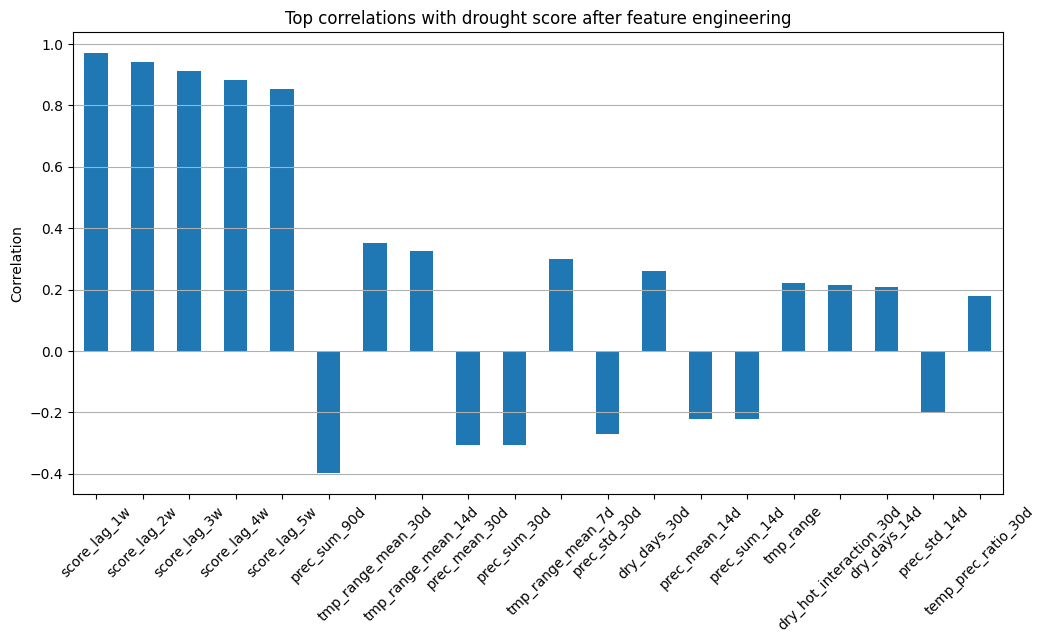

In [33]:
import matplotlib.pyplot as plt

top_corr = corr_with_score.head(20)

plt.figure(figsize=(12,6))
top_corr.plot(kind="bar")
plt.title("Top correlations with drought score after feature engineering")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

### Interpretation
The engineered temporal features showed stronger correlations with the drought score than the original daily meteorological variables, suggesting that aggregated temporal patterns are more informative for drought prediction than instantaneous observations.